In [18]:
#kaggle.com/datasets/uciml/iris
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("iris.csv", index_col="Id")

## 1. Первичный анализ данных

In [19]:
X = data.drop(columns=["Species"])
y = data["Species"]

In [20]:
print(data.shape)
print(data.info())
print("Пропуски")
print(data.isnull().sum())
print("Таргет")
print(y.nunique(), y.unique())

(150, 5)
<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB
None
Пропуски
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Таргет
3 ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [21]:
X.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


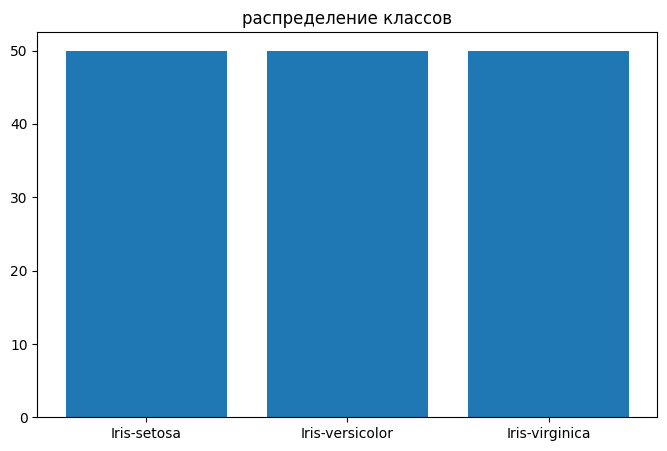

In [22]:
plt.figure(figsize=(8, 5))
counts = y.value_counts()
plt.bar(counts.index, counts.values)
plt.title("распределение классов")
plt.show()



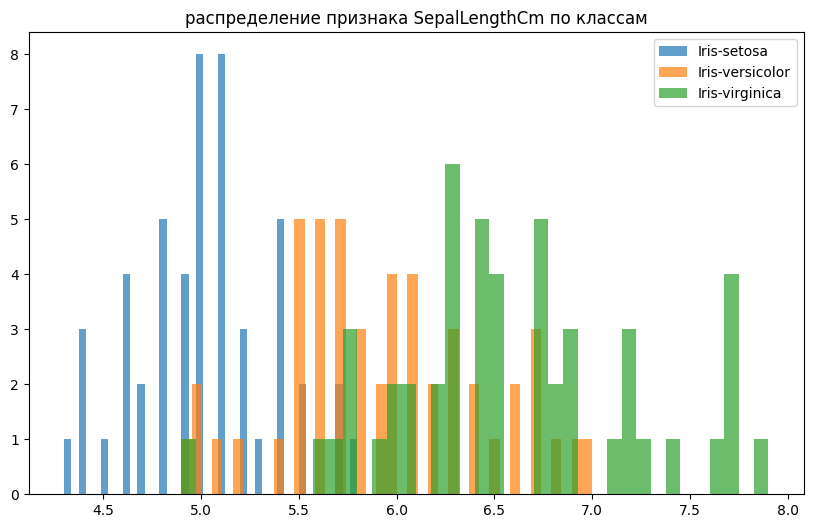

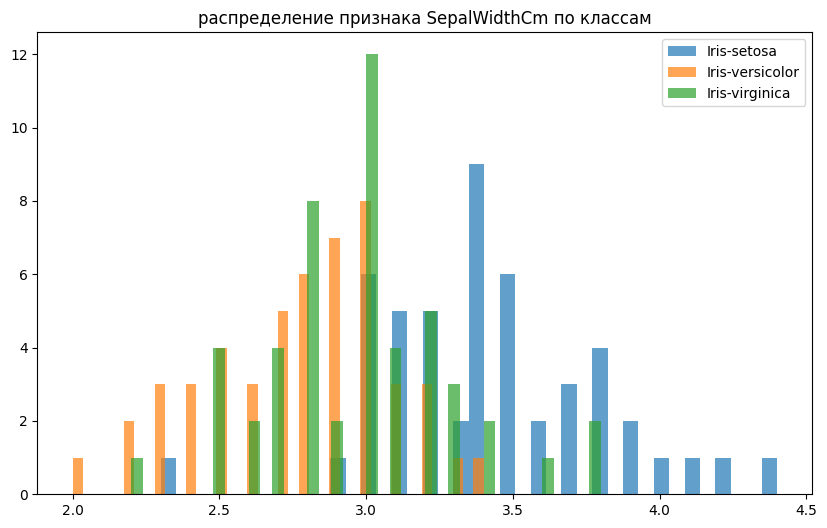

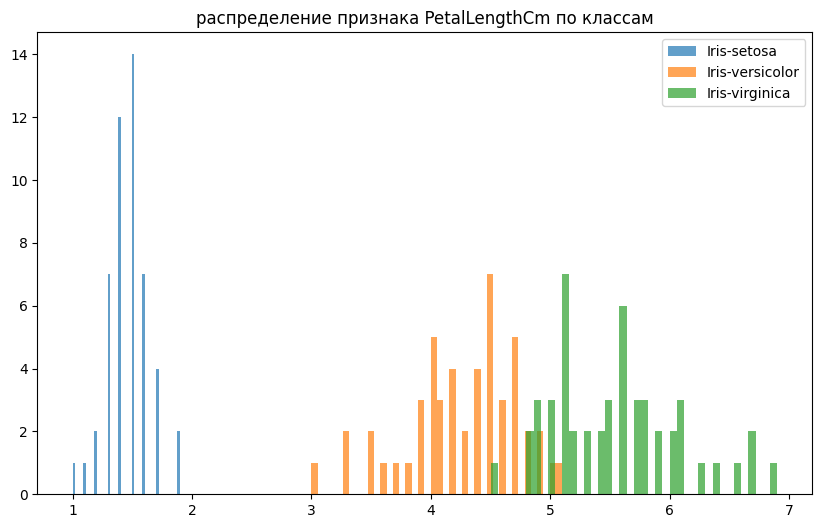

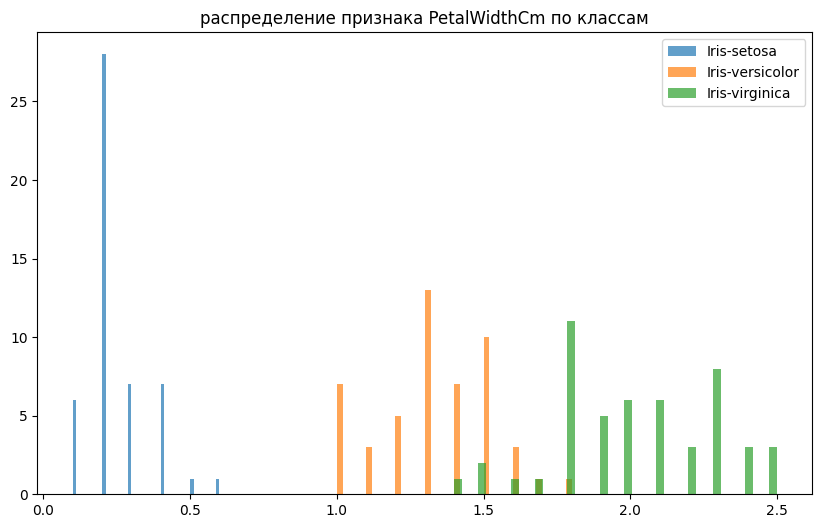

In [23]:
for column in X.columns:
    plt.figure(figsize=(10, 6))
    plt.title(f"распределение признака {column} по классам")
    for specie in y.unique():
        indexes = np.where(y == specie)
        plt.hist(X[column].iloc[indexes], bins=40, alpha=0.7, label = specie)
    plt.legend()
    plt.show()
    

## 3. Подготовка данных

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3, stratify=y)
scaler = StandardScaler()
scaler.fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)

## Ответы на вопросы


1.масштабирование важно для knn потому что в формуле расстояния все признаки равны, хотя например один может измерятьс яв тысячах, а другой в единицах. Без масштабирования алгоритм будет работать не так точно как мог бы



2.таким образом завышается результат модели т.к. тестовые данные учавствуют в построении модели и когда модель столкнётся с реальными данными её качество может значительно упасть

## 4. Обучение модели и подбор гиперпараметров

## С масштабированием

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
metrics = ['euclidean', 'manhattan', 'minkowski', 'cosine']
ks = list(range(1, 89, 1))
weights_options = ['uniform', 'distance']
results = []
for metric in metrics:
    for weights in weights_options:
        for k in ks:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weights, n_jobs=-1)
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=3)
            scores = cross_val_score(knn, X_train_s, y_train, cv=cv, scoring="accuracy")

            mean_score = scores.mean()
            results.append([metric, weights, k, mean_score])


In [26]:
to_ponder = pd.DataFrame(results, columns=["metric", "weights", "k", "score"])

In [27]:
print(to_ponder.head())
print(to_ponder["score"].mean())
best10 = to_ponder["score"].nlargest(10).index
print(to_ponder["score"].nlargest(10))

      metric  weights  k     score
0  euclidean  uniform  1  0.975000
1  euclidean  uniform  2  0.966667
2  euclidean  uniform  3  0.966667
3  euclidean  uniform  4  0.958333
4  euclidean  uniform  5  0.966667
0.8867660984848484
102    0.983333
282    0.983333
283    0.983333
284    0.983333
454    0.983333
0      0.975000
88     0.975000
89     0.975000
91     0.975000
92     0.975000
Name: score, dtype: float64


In [28]:
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
results = []
best_acur = 0
best_row = None
for i in best10:
    row = to_ponder.iloc[i]
    row.drop("score")
    knn = KNeighborsClassifier(n_neighbors=row["k"], metric=row["metric"], weights=row["weights"], n_jobs=-1)
    knn.fit(X_train_s, y_train)
    y_preds = knn.predict(X_test_s)
    acur = (y_preds == y_test).astype(np.int32).mean()
    results.append(acur)
    if acur > best_acur:
        best_acur = acur
        best_row = row.drop("score")
print(best_acur)
print(best_row)

0.9333333333333333
metric     euclidean
weights     distance
k                  5
Name: 92, dtype: object


## Без масштабирование

In [29]:
metrics = ['euclidean', 'manhattan', 'minkowski', 'cosine']
ks = list(range(1, 89, 1))
weights_options = ['uniform', 'distance']
results_2 = []
for metric in metrics:
    for weights in weights_options:
        for k in ks:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weights, n_jobs=-1)
            cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=3)
            scores = cross_val_score(knn, X_train, y_train, cv=cv, scoring="accuracy")

            mean_score = scores.mean()
            results_2.append([metric, weights, k, mean_score])
to_ponder_2 = pd.DataFrame(results_2, columns=["metric", "weights", "k", "score"])
print(to_ponder_2.head())
print(to_ponder_2["score"].mean())
best10_2 = to_ponder_2["score"].nlargest(10).index
print(to_ponder_2["score"].nlargest(10))

      metric  weights  k     score
0  euclidean  uniform  1  0.966667
1  euclidean  uniform  2  0.958333
2  euclidean  uniform  3  0.975000
3  euclidean  uniform  4  0.975000
4  euclidean  uniform  5  0.975000
0.9189512310606059
590    1.000000
587    0.991667
101    0.983333
102    0.983333
103    0.983333
104    0.983333
105    0.983333
106    0.983333
107    0.983333
108    0.983333
Name: score, dtype: float64


In [ ]:
results_2 = []
best_acur_2 = 0
best_row_2 = None
for i in best10_2:
    row = to_ponder_2.iloc[i]
    row.drop("score")
    knn = KNeighborsClassifier(n_neighbors=row["k"], metric=row["metric"], weights=row["weights"], n_jobs=-1)
    knn.fit(X_train, y_train)
    y_preds = knn.predict(X_test)
    acur = (y_preds == y_test).astype(np.int32).mean()
    results.append(acur)
    if acur > best_acur_2:
        best_acur_2 = acur
        best_row_2 = row.drop("score")
print(best_acur_2)
print(best_row_2)

0.9666666666666667
metric      cosine
weights    uniform
k               63
Name: 590, dtype: object


: 

![...](https://media2.giphy.com/media/v1.Y2lkPTc5MGI3NjExNW82aWs1M3g2dGJ4OTRoeWZia3hwZ2EyOHByY214YzZ4aDUwcG1vYyZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/A2zW1iISwdXsOXNaRd/giphy.gif)

## Выводы

На удивление получилось так что результат на тесте без масштабирования выше, чем с масштабированием
по моему мнению причинами может оказаться следующие факты:
1. все признаки измеряются в сантиметрах 
2. датасет маленький всего 150 сэмплов
3. при маштабировании теряется информация, как было видно по графикам распределений для классов до масштабирования по некоторым прищнакам на глаз можно легко разделить на классы